In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [4]:
# Load Dataset
digits = datasets.load_digits()

print("Number of Rows (Samples):", digits.data.shape[0])
print("Number of Columns (Features):", digits.data.shape[1])
print("Feature Names:", digits.feature_names if hasattr(digits, 'feature_names') else "Image pixels (8x8)")
print("Target Classes:", np.unique(digits.target))

Number of Rows (Samples): 1797
Number of Columns (Features): 64
Feature Names: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
Target Classes: [0 1 2 3 4 5 6 7 8 9]


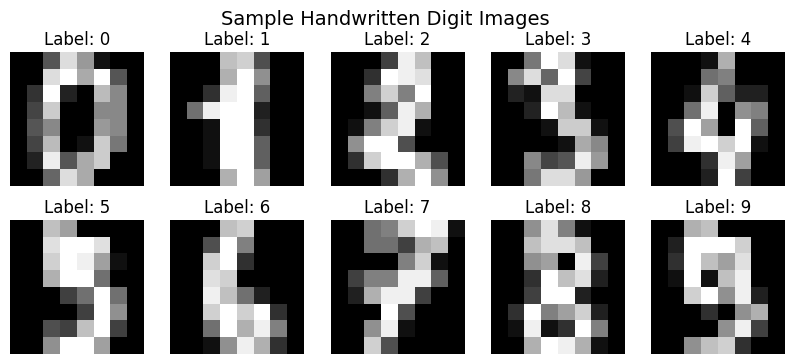

In [5]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f'Label: {digits.target[i]}')
    plt.axis('off')
plt.suptitle("Sample Handwritten Digit Images", fontsize=14)
plt.show()

In [6]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)

In [7]:
# Train SVM Model
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', gamma='scale')
svm_model.fit(X_train, y_train)

# Predictions
y_pred = svm_model.predict(X_test)

In [8]:
# Evaluation Metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
error_rate = 1 - accuracy

# Display Results
print("\n--- SVM Results ---")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("Error Rate:", round(error_rate, 4))


--- SVM Results ---
Accuracy: 0.9861
Precision: 0.9872
Recall: 0.9866
Error Rate: 0.0139


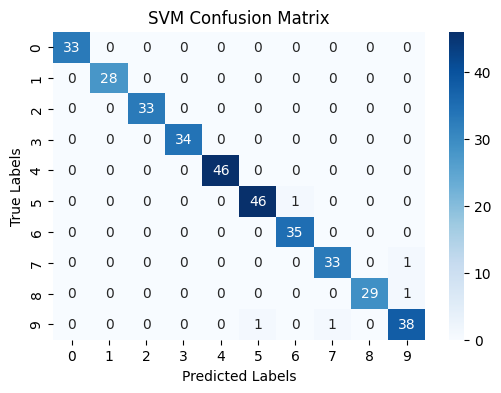

In [10]:
# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

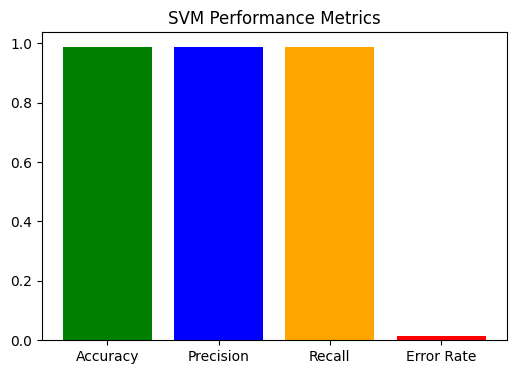

In [9]:
# Bar Chart of Metrics
plt.figure(figsize=(6,4))
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'Error Rate': error_rate}
plt.bar(metrics.keys(), metrics.values(), color=['green', 'blue', 'orange', 'red'])
plt.title("SVM Performance Metrics")
plt.show()